# Klasifikasi Kesesuaian Judul-Isi Berita

## Pipeline Overview
1. Instalasi Library
2. Import & Konfigurasi
3. Load Data (Kaggle API)
4. Preprocessing (dengan Checkpoint)
5. Feature Engineering - Leksikal (TF-IDF, BM25, Jaccard)
6. Feature Engineering - Semantik (FastText)
7. Gabungan Fitur Matriks
8. Optuna Tuning (LightGBM)
9. K-Fold Ensemble (LightGBM + XGBoost)
10. Threshold Tuning
11. Export Submission
12. Visualisasi

## 1. Instalasi Library
Menginstall seluruh library yang dibutuhkan: XGBoost, LightGBM, Optuna, rank_bm25, gensim (FastText), Sastrawi (stemming Bahasa Indonesia), dan kagglehub.

In [1]:
%pip install -q xgboost lightgbm optuna rank_bm25 gensim Sastrawi tqdm pandas numpy scikit-learn scipy matplotlib seaborn kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 1.8 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


## 2. Import Library & Konfigurasi
Mengimport semua library dan mengunci seed (42) untuk reproduksibilitas.

In [2]:
import os, random, warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp

import lightgbm as lgb
import xgboost as xgb
import optuna

from gensim.models import FastText
from rank_bm25 import BM25Okapi

SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(SEED)
print(f'Seed locked globally at: {SEED}')

Seed locked globally at: 42


## 3. Load Data dari Kaggle
Menggunakan kagglehub untuk mengunduh dataset kompetisi. Tahap ini juga:
- Menghapus data duplikat
- Menangani missing values
- Menghitung rasio kelas imbalance untuk XGBoost

In [3]:
import kagglehub

# ==========================================
# LOAD DATA (untuk VSCode / lokal)
# ==========================================
DATA_DIR = "./data"  # Sesuaikan dengan lokasi file kamu

train = pd.read_csv(os.path.join(DATA_DIR, '/kaggle/input/competitions/penyisihan-ifest-2026-dac/train.csv'))
test = pd.read_csv(os.path.join(DATA_DIR, '/kaggle/input/competitions/penyisihan-ifest-2026-dac/test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, '/kaggle/input/competitions/penyisihan-ifest-2026-dac/sample_submission.csv'))

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')


# 1. Hapus Duplikat
print('\n=== CEK DUPLIKAT ===')
print('Duplikat awal di Train:', train.duplicated(subset=['title', 'content']).sum())
train = train.drop_duplicates(subset=['title', 'content'], keep='first').reset_index(drop=True)
print('Sisa duplikat di Train:', train.duplicated(subset=['title', 'content']).sum())

# 2. Handle Missing Values
print('\n=== CEK MISSING VALUES ===')
train = train.dropna(subset=['title', 'content', 'label']).reset_index(drop=True)
test['title'] = test['title'].fillna('').astype(str)
test['content'] = test['content'].fillna('').astype(str)
print('Missing values dibersihkan.')

# 3. Hitung rasio imbalance
ratio = train['label'].value_counts()[0] / train['label'].value_counts()[1]
print(f'\nRasio Kelas (0/1) untuk XGBoost: {ratio:.2f}')

Train shape: (14397, 4)
Test shape: (3603, 3)

=== CEK DUPLIKAT ===
Duplikat awal di Train: 3
Sisa duplikat di Train: 0

=== CEK MISSING VALUES ===
Missing values dibersihkan.

Rasio Kelas (0/1) untuk XGBoost: 0.11


### Visualisasi: Distribusi Kelas
Menampilkan distribusi label kelas (Sesuai vs Tidak Sesuai) dalam bar chart dan pie chart.

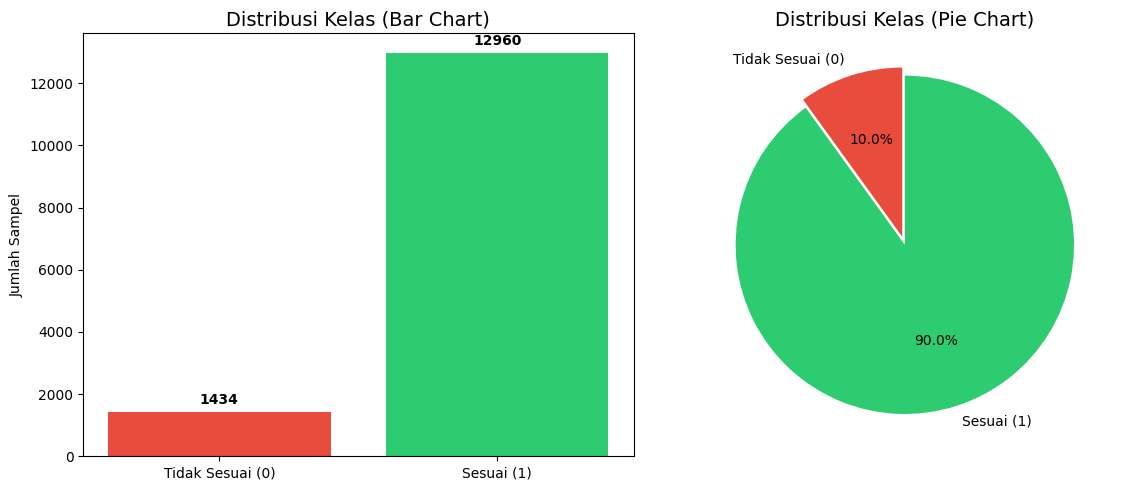

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = train['label'].value_counts().sort_index()
labels = ['Tidak Sesuai (0)', 'Sesuai (1)']
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Distribusi Kelas (Bar Chart)', fontsize=14)
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + (max(counts)*0.02), str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
axes[1].set_title('Distribusi Kelas (Pie Chart)', fontsize=14)

plt.tight_layout()
plt.show()

## 4. Preprocessing Teks

In [5]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer = StemmerFactory().create_stemmer()
stopword = StopWordRemoverFactory().create_stop_word_remover()

def clean_text(text, max_words=None):
    if not isinstance(text, str): text = str(text)
    if max_words:
        text = ' '.join(text.split()[:max_words])
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword.remove(text)
    text = stemmer.stem(text)
    return text

print('Memulai preprocessing data train...')
train['clean_title'] = train['title'].progress_apply(lambda x: clean_text(x, max_words=None))
train['clean_content'] = train['content'].progress_apply(lambda x: clean_text(x, max_words=256))

print('Memulai preprocessing data test...')
test['clean_title'] = test['title'].progress_apply(lambda x: clean_text(x, max_words=None))
test['clean_content'] = test['content'].progress_apply(lambda x: clean_text(x, max_words=256))

print('Preprocessing selesai.')

File checkpoint ditemukan! Memuat data yang sudah diproses...
Train shape: (14394, 11)
Test shape: (3603, 10)


### Visualisasi: Distribusi Panjang Teks
Histogram distribusi jumlah kata pada judul dan isi berita.

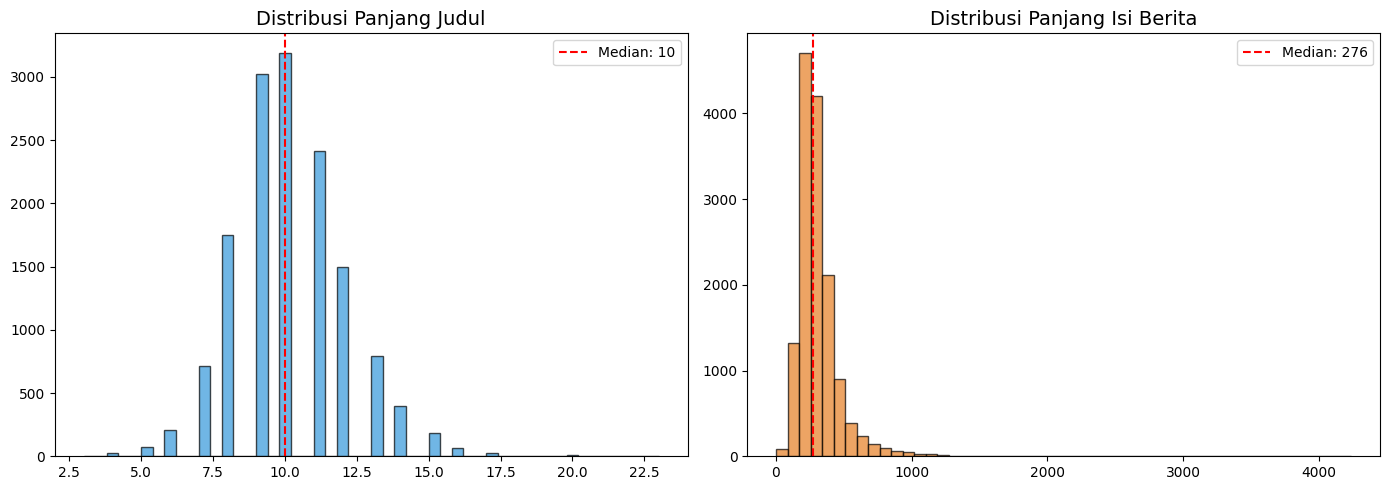

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
title_len = train['title'].astype(str).apply(lambda x: len(x.split()))
content_len = train['content'].astype(str).apply(lambda x: len(x.split()))

axes[0].hist(title_len, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Panjang Judul', fontsize=14)
axes[0].axvline(title_len.median(), color='red', linestyle='--', label=f'Median: {title_len.median():.0f}')
axes[0].legend()

axes[1].hist(content_len, bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Panjang Isi Berita', fontsize=14)
axes[1].axvline(content_len.median(), color='red', linestyle='--', label=f'Median: {content_len.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Feature Engineering - Fitur Leksikal (TF-IDF, BM25, Jaccard)
Mengekstrak fitur kemiripan teks:
- **TF-IDF Cosine Similarity**: Kemiripan vektor TF-IDF antara judul dan isi
- **Jaccard Similarity**: Rasio kata yang sama antara judul dan isi
- **BM25 Score**: Skor relevansi berbasis algoritma mesin pencari
- **Length Ratio**: Rasio panjang isi terhadap judul

**Penting**: TF-IDF dan BM25 hanya di-fit di data train untuk menghindari data leakage.

In [7]:
print('Ekstraksi Fitur TF-IDF & BM25...')

# 1. TF-IDF (HANYA fit di train)
train['clean_title'] = train['clean_title'].fillna('').astype(str)
train['clean_content'] = train['clean_content'].fillna('').astype(str)
test['clean_title'] = test['clean_title'].fillna('').astype(str)
test['clean_content'] = test['clean_content'].fillna('').astype(str)

train_text = train['clean_title'].tolist() + train['clean_content'].tolist()

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
tfidf.fit(train_text)

train_title_tfidf = tfidf.transform(train['clean_title'])
train_content_tfidf = tfidf.transform(train['clean_content'])
test_title_tfidf = tfidf.transform(test['clean_title'])
test_content_tfidf = tfidf.transform(test['clean_content'])

train_contents_tokenized = [str(doc).split() for doc in train['clean_content'].tolist()]
bm25_model = BM25Okapi(train_contents_tokenized)

def compute_jaccard(title, content):
    set_t, set_c = set(str(title).split()), set(str(content).split())
    if not set_t or not set_c: return 0.0
    return len(set_t.intersection(set_c)) / len(set_t.union(set_c))

def compute_bm25_row(title, content, bm25_obj):
    query = str(title).split()
    doc_words = str(content).split()
    doc_len = len(doc_words)
    score = 0.0
    for word in query:
        if word in bm25_obj.idf:
            idf = bm25_obj.idf[word]
            tf = doc_words.count(word)
            score += idf * (tf * (bm25_obj.k1 + 1)) / (tf + bm25_obj.k1 * (1 - bm25_obj.b + bm25_obj.b * (doc_len / bm25_obj.avgdl)))
    return score

for df, title_mat, content_mat in [(train, train_title_tfidf, train_content_tfidf), 
                                   (test, test_title_tfidf, test_content_tfidf)]:
    df['jaccard_sim'] = df.apply(lambda x: compute_jaccard(x['clean_title'], x['clean_content']), axis=1)
    df['tfidf_cosine_sim'] = title_mat.multiply(content_mat).sum(axis=1).A1
    df['length_ratio'] = df['clean_content'].apply(lambda x: len(str(x).split())) / \
                         (df['clean_title'].apply(lambda x: len(str(x).split())) + 1e-5)
    df['bm25_score'] = df.apply(lambda x: compute_bm25_row(x['clean_title'], x['clean_content'], bm25_model), axis=1)

print('Fitur Lexical & BM25 selesai!')

Ekstraksi Fitur TF-IDF & BM25...
Fitur Lexical & BM25 selesai!


## 6. Feature Engineering - Fitur Semantik (FastText)
Melatih model FastText dari awal (sesuai rules) untuk menangkap makna kata berbasis sub-word. Cosine similarity antara vektor judul dan isi digunakan sebagai fitur semantik.

In [8]:
print('Melatih FastText dari awal (Legal)...')

train_sentences = [str(text).split() for text in train_text]

ft_model = FastText(sentences=train_sentences, vector_size=100, window=5, min_count=2, workers=4, seed=SEED)

def get_avg_ft_vector(text, model, vector_size=100):
    words = str(text).split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    if not vectors: return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

for df in [train, test]:
    title_ft = np.array([get_avg_ft_vector(t, ft_model) for t in df['clean_title']])
    content_ft = np.array([get_avg_ft_vector(c, ft_model) for c in df['clean_content']])
    
    dot_product = np.sum(title_ft * content_ft, axis=1)
    norm_title = np.linalg.norm(title_ft, axis=1)
    norm_content = np.linalg.norm(content_ft, axis=1)
    
    df['fasttext_cosine_sim'] = dot_product / (norm_title * norm_content + 1e-10)

print('Fitur Semantik FastText selesai!')

Melatih FastText dari awal (Legal)...
Fitur Semantik FastText selesai!


### Visualisasi: Distribusi Fitur per Label
Distribusi Jaccard, BM25 Score, dan FastText Cosine per kelas label.

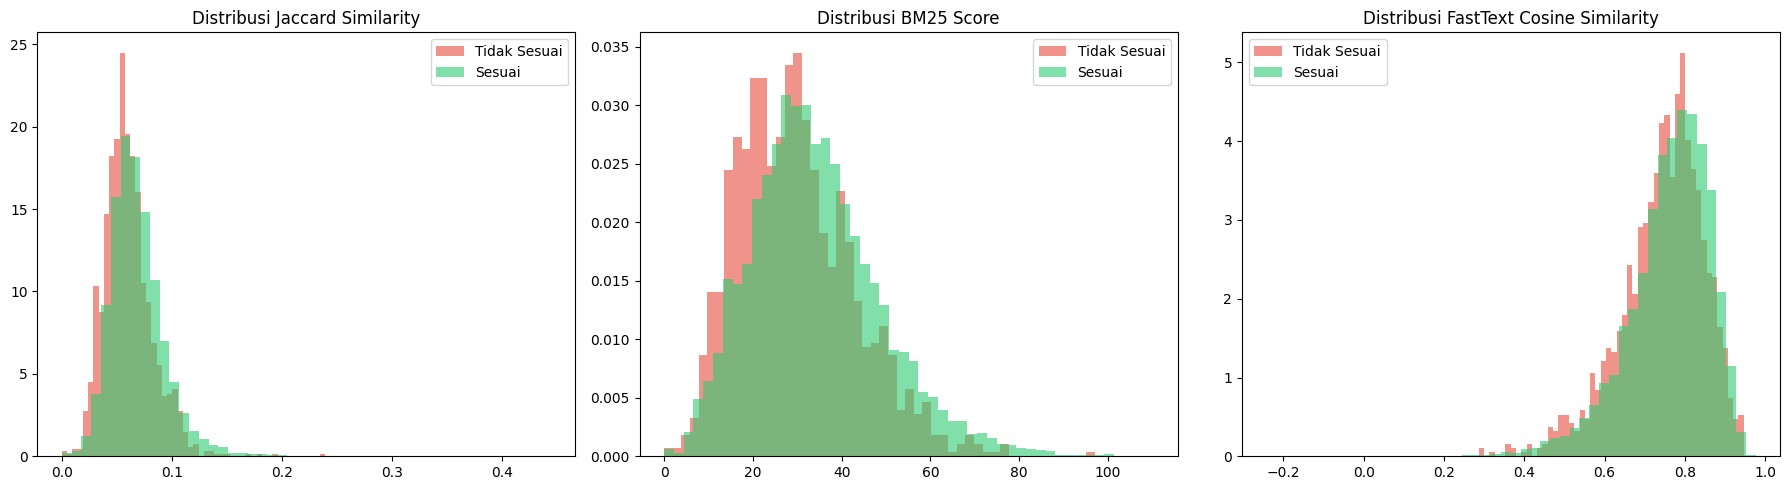

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['jaccard_sim', 'bm25_score', 'fasttext_cosine_sim']
titles = ['Jaccard Similarity', 'BM25 Score', 'FastText Cosine Similarity']

for ax, feat, title in zip(axes, features, titles):
    if feat not in train.columns: continue
    for label, color, name in [(0, '#e74c3c', 'Tidak Sesuai'), (1, '#2ecc71', 'Sesuai')]:
        subset = train[train['label'] == label][feat]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(f'Distribusi {title}', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Gabungan Matriks Fitur
Menggabungkan matriks TF-IDF (judul + isi) dengan fitur numerik tambahan menjadi satu matriks sparse untuk input model.

In [10]:
print('Menggabungkan matriks (TF-IDF + Features)...')

extra_cols = ['jaccard_sim', 'tfidf_cosine_sim', 'length_ratio', 'bm25_score', 'fasttext_cosine_sim']

X_train = sp.hstack([train_title_tfidf, train_content_tfidf, train[extra_cols].values]).tocsr()
X_test = sp.hstack([test_title_tfidf, test_content_tfidf, test[extra_cols].values]).tocsr()
y_train = train['label'].values

print(f'Dimensi X_train: {X_train.shape}')

Menggabungkan matriks (TF-IDF + Features)...
Dimensi X_train: (14394, 20005)


## 8. Hyperparameter Optimization (Optuna)
Mencari parameter terbaik untuk LightGBM menggunakan Optuna dengan 50 trials dan 3-Fold Cross Validation.

In [11]:
N_TRIALS = 50

def objective_lgb(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'class_weight': 'balanced',
        'boosting_type': 'gbdt',
        'random_state': SEED,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'verbose': -1
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    f1_scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train[train_idx], y_train[train_idx]
        X_val, y_val = X_train[val_idx], y_train[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        preds = (model.predict_proba(X_val)[:, 1] >= 0.5).astype(int)
        f1_scores.append(f1_score(y_val, preds, average='macro'))
        
    return np.mean(f1_scores)

print('Memulai Optuna Tuning untuk LightGBM...')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS)

best_lgb_params = study_lgb.best_params
best_lgb_params['class_weight'] = 'balanced'
best_lgb_params['random_state'] = SEED
best_lgb_params['verbose'] = -1
print('Best LightGBM Params:', best_lgb_params)

Memulai Optuna Tuning untuk LightGBM...
Best LightGBM Params: {'learning_rate': 0.021496898030291187, 'n_estimators': 215, 'max_depth': 8, 'num_leaves': 58, 'subsample': 0.8828446847409368, 'colsample_bytree': 0.9484518637332248, 'class_weight': 'balanced', 'random_state': 42, 'verbose': -1}


## 9. K-Fold Cross Validation Ensemble
Melatih LightGBM dan XGBoost dengan 5-Fold Stratified Cross Validation. Probabilitas dari kedua model digabungkan (50:50 blending).

In [12]:
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)

oof_preds_lgb = np.zeros(X_train.shape[0])
test_preds_lgb = np.zeros(X_test.shape[0])
oof_preds_xgb = np.zeros(X_train.shape[0])
test_preds_xgb = np.zeros(X_test.shape[0])

xgb_params = {
    'random_state': SEED,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'max_depth': 6,
    'scale_pos_weight': ratio,
    'eval_metric': 'logloss',
    'use_label_encoder': False
}

print('Melatih Model Ensemble (LightGBM + XGBoost)...')
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, y_tr = X_train[train_idx], y_train[train_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]
    
    # LightGBM
    model_lgb = lgb.LGBMClassifier(**best_lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])
    oof_preds_lgb[val_idx] = model_lgb.predict_proba(X_val)[:, 1]
    test_preds_lgb += model_lgb.predict_proba(X_test)[:, 1] / n_folds
    
    # XGBoost
    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_preds_xgb[val_idx] = model_xgb.predict_proba(X_val)[:, 1]
    test_preds_xgb += model_xgb.predict_proba(X_test)[:, 1] / n_folds
    
    print(f'Fold {fold+1} Selesai.')

oof_preds_ensemble = (oof_preds_lgb * 0.5) + (oof_preds_xgb * 0.5)
test_preds_ensemble = (test_preds_lgb * 0.5) + (test_preds_xgb * 0.5)

Melatih Model Ensemble (LightGBM + XGBoost)...
Fold 1 Selesai.
Fold 2 Selesai.
Fold 3 Selesai.
Fold 4 Selesai.
Fold 5 Selesai.


## 10. Threshold Tuning (Macro F1)
Mencari threshold optimal yang memaksimalkan Macro F1-Score pada data OOF.

In [13]:
print('\n=== MENCARI THRESHOLD OPTIMAL (MACRO F1) ===')
best_th, best_f1 = 0.5, 0.0

for th in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_train, (oof_preds_ensemble >= th).astype(int), average='macro')
    if f1 > best_f1:
        best_f1, best_th = f1, th

print(f'Macro F1 @0.50             : {f1_score(y_train, (oof_preds_ensemble>=0.5).astype(int), average="macro"):.4f}')
print(f'Threshold optimal          : {best_th:.2f}')
print(f'Macro F1 @threshold opt    : {best_f1:.4f}')

final_oof_classes = (oof_preds_ensemble >= best_th).astype(int)
print('\nClassification report (OOF, threshold optimal):')
print(classification_report(y_train, final_oof_classes, target_names=['Tidak Sesuai (0)', 'Sesuai (1)']))


=== MENCARI THRESHOLD OPTIMAL (MACRO F1) ===
Macro F1 @0.50             : 0.5679
Threshold optimal          : 0.48
Macro F1 @threshold opt    : 0.5741

Classification report (OOF, threshold optimal):
                  precision    recall  f1-score   support

Tidak Sesuai (0)       0.21      0.30      0.25      1434
      Sesuai (1)       0.92      0.88      0.90     12960

        accuracy                           0.82     14394
       macro avg       0.57      0.59      0.57     14394
    weighted avg       0.85      0.82      0.83     14394



### Visualisasi: Confusion Matrix
Menampilkan confusion matrix absolut dan ternormalisasi dari prediksi OOF.

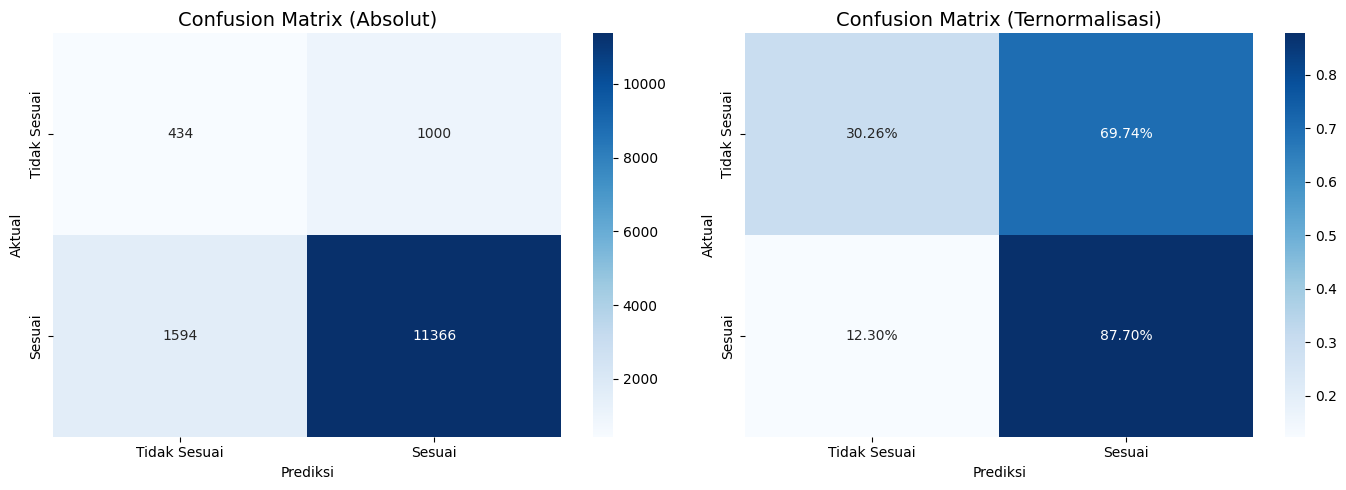

In [14]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_train, final_oof_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Tidak Sesuai', 'Sesuai'], yticklabels=['Tidak Sesuai', 'Sesuai'])
axes[0].set_title('Confusion Matrix (Absolut)', fontsize=14)
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Tidak Sesuai', 'Sesuai'], yticklabels=['Tidak Sesuai', 'Sesuai'])
axes[1].set_title('Confusion Matrix (Ternormalisasi)', fontsize=14)
axes[1].set_ylabel('Aktual')
axes[1].set_xlabel('Prediksi')

plt.tight_layout()
plt.show()

## 11. Export Submission
Membuat file submission.csv dengan format yang sesuai (id, label).

In [15]:
print('\n=== MEMBUAT PREDIKSI DATA TEST ===')
test_preds_probs = test_preds_ensemble
test_labels = (test_preds_probs >= best_th).astype(int)

try:
    sample_sub = pd.read_csv(os.path.join(path, '/kaggle/input/competitions/penyisihan-ifest-2026-dac/sample_submission.csv'))
except:
    sample_sub = pd.DataFrame({'id': test['id'] if 'id' in test.columns else [f'te{i:05d}' for i in range(len(test))]})

sample_sub['label'] = test_labels
sample_sub.to_csv('submission.csv', index=False)

print(f'\nSubmission saved! Distribusi prediksi kelas:')
print(sample_sub['label'].value_counts())
print(f'\nFile submission.csv berhasil dibuat di:')
print(os.path.abspath('submission.csv'))
print('\nSample:')
print(sample_sub.head(10))


=== MEMBUAT PREDIKSI DATA TEST ===

Submission saved! Distribusi prediksi kelas:
label
1    3177
0     426
Name: count, dtype: int64

File submission.csv berhasil dibuat di:
/kaggle/working/submission.csv

Sample:
        id  label
0  te00000      0
1  te00001      0
2  te00002      1
3  te00003      1
4  te00004      1
5  te00005      1
6  te00006      1
7  te00007      1
8  te00008      1
9  te00009      1
